In [60]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from PIL import Image
from io import BytesIO
plt.rc('xtick', labelsize=20) 
plt.rc('ytick', labelsize=20)

def eV2au(eV: float):
    return 0.036749325871*eV

def nm2au(nm: float):
    return 18.897261339*nm

def kV_cm2au(kV_cm: float):
    constant = (1.0/27.211)*0.0529*0.0001
    return constant*kV_cm

def au2ns(s: np.ndarray):
    return s*2.418884e-8

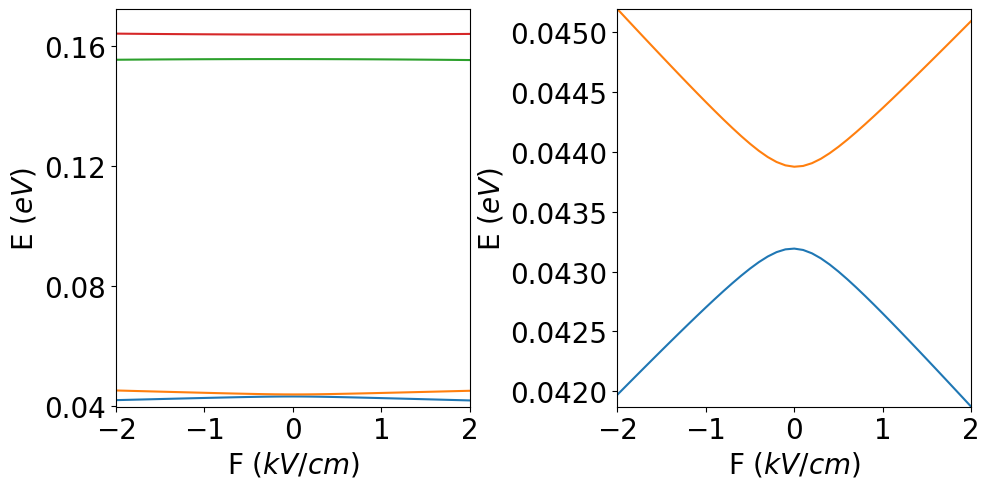

0.6842999999999988  meV


In [88]:
data1 = np.loadtxt('z1.dat')
linsp = np.linspace(-2, 2, len(data1))

fig, ax = plt.subplots(1,2, figsize=(10, 5))
#fig.suptitle("Zależność energii od pola elektrycznego", fontsize=20)

for i in range(4):
    ax[0].plot(linsp, data1[:,i], label = f"mod {i}")
ax[0].set_xlabel("F ($kV/cm$)", fontsize = 20)
ax[0].set_ylabel("E ($eV$)", fontsize = 20)
ax[0].set_xticks([-2,-1,0,1,2])
ax[0].set_yticks([0.04, 0.08, 0.12, 0.16, 0.2])
ax[0].set_xlim(-2, 2)
ax[0].set_ylim(.95*np.min(data1[:,0]), 1.05*np.max(data1[:,3]))
#ax[0].grid(True)

for i in range(2):
    ax[1].plot(linsp, data1[:,i], label = f"mod {i}")
ax[1].set_xlabel(r"F ($kV/cm$)", fontsize = 20)
ax[1].set_ylabel(r"E ($eV$)", fontsize = 20)
ax[1].set_xticks([-2,-1,0,1,2])
ax[1].set_xlim(-2, 2)
ax[1].set_ylim(np.min(data1[:,0]), np.max(data1[:,1]))
#ax[1].grid(True)

fig.tight_layout()
plt.show()

print(1000*(data1[len(data1[:,0])//2,1] - data1[len(data1[:,1])//2,0]), " meV")

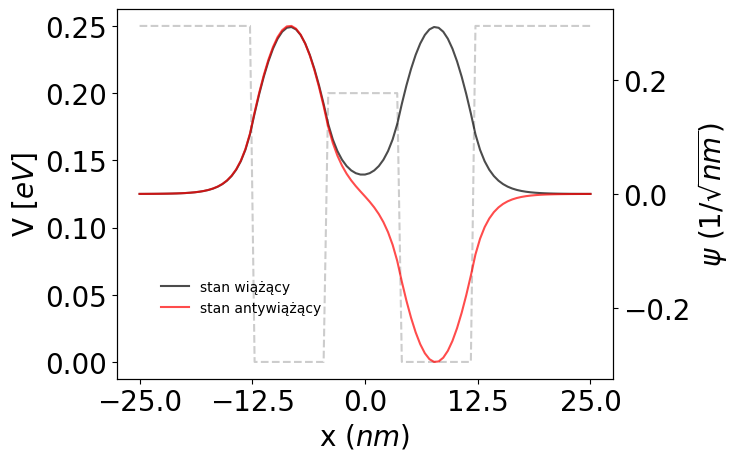

In [82]:
data2 = np.loadtxt('z2.dat')
linsp = np.linspace(-25, 25, len(data2[0]))

fig, ax = plt.subplots()

ax.plot(linsp, data2[0]/eV2au(1.0), '--', color='Gray', alpha = 0.4)
ax.set_ylabel(r"V [$eV$]", fontsize = 20)
ax.set_xlabel("x ($nm$)", fontsize = 20)
ax.set_xticks([-25,-12.5,0,12.5,25])
ax_twin = ax.twinx()

data2_1_sqrtnm = data2[1]*np.sqrt(nm2au(1.0))
data2_2_sqrtnm = data2[2]*np.sqrt(nm2au(1.0))

ax_twin.plot(linsp, data2_1_sqrtnm, label = 'stan wiążący', color = 'k', alpha = 0.7)
ax_twin.plot(linsp, data2_2_sqrtnm, label = 'stan antywiążący', color = 'r', alpha = 0.7)
ax_twin.set_ylabel(r"$\psi$ $(1/\sqrt{nm})$", fontsize = 20)
ax_twin.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.25, 0.3))

plt.show()

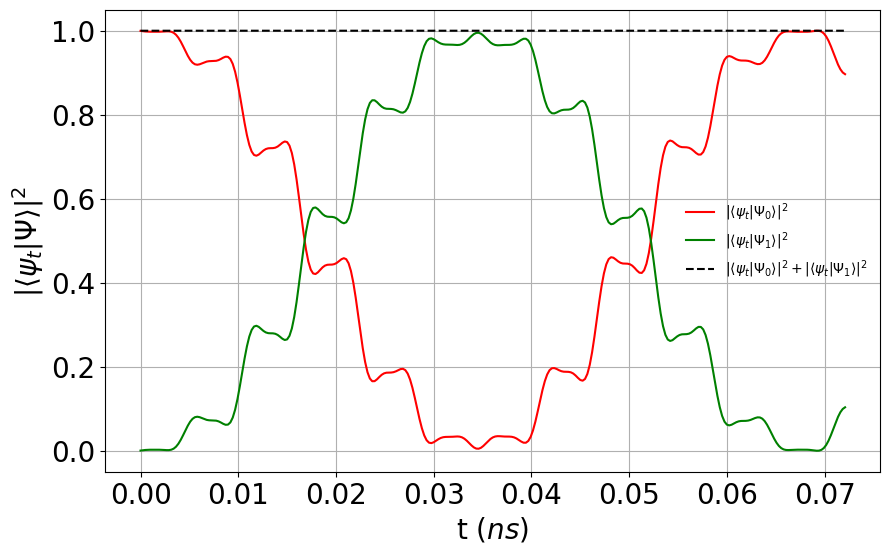

In [80]:
dane3 = np.loadtxt('z3.dat')
linsp_t = 10000*au2ns(np.arange(0, len(dane3[:-1,0])))

plt.figure(figsize=(10, 6))
plt.plot(linsp_t, dane3[:-1,0], label = r"$|\langle\psi_t|\Psi_0\rangle|^2$", color = 'r')
plt.plot(linsp_t, dane3[:-1,1], label = r"$|\langle\psi_t|\Psi_1\rangle|^2$", color = 'g')
plt.xlabel('t ($ns$)', fontsize = 20)
plt.ylabel(r"$|\langle\psi_t|\Psi\rangle|^2$", fontsize = 20)
plt.grid(True)
plt.plot(linsp_t, dane3[:-1,0] + dane3[:-1,1], '--',
        label = r"$|\langle\psi_t|\Psi_0\rangle|^2+|\langle\psi_t|\Psi_1\rangle|^2$", color = 'k')
plt.legend(frameon=False)
plt.show()

# GIF

In [98]:
dane3_psi = np.loadtxt('z3_psi.dat')
linsp = np.linspace(-25, 25, len(dane3_psi[0]))

omega = 0.0000095*2.418884
F_val = kV_cm2au(0.08)

def F(linsp: np.ndarray, t: float):
    return F_val*nm2au(linsp)*np.sin(omega*t)

folder = 'psi_t'
os.makedirs(folder, exist_ok=True)
output_gif = 'psi_in_time.gif'
images = []

for idx in range(len(dane3_psi)):
    fig, ax = plt.subplots()
    ax.plot(linsp, (data2[0] + F(linsp, idx))/eV2au(1.0), '--', color='Gray', alpha=0.4)
    ax.set_xticks([-25, -12.5, 0, 12.5, 25])
    ax.set_ylabel(r"$V$ $(eV)$", fontsize=20, color='Gray')
    ax.set_xlabel(r"x ($nm$)", fontsize=20)

    ax_twin = ax.twinx()
    ax_twin.plot(linsp, dane3_psi[idx]*nm2au(1.0), color='k')
    ax_twin.set_ylabel(r"$|\psi|^2$ $(1/nm)$", fontsize=20)
    ax_twin.set_ylim((0.0, 0.01*nm2au(1.0)))
    fig.tight_layout()
    
    buf = BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    images.append(Image.open(buf))

    plt.close()

if not images:
    pass
else:
    try:
        images[0].save(output_gif, save_all=True, append_images=images[1:], duration=200)
        print(f"{output_gif} gotowy")
    except Exception as e:
        print(e)
        pass

psi_in_time.gif gotowy


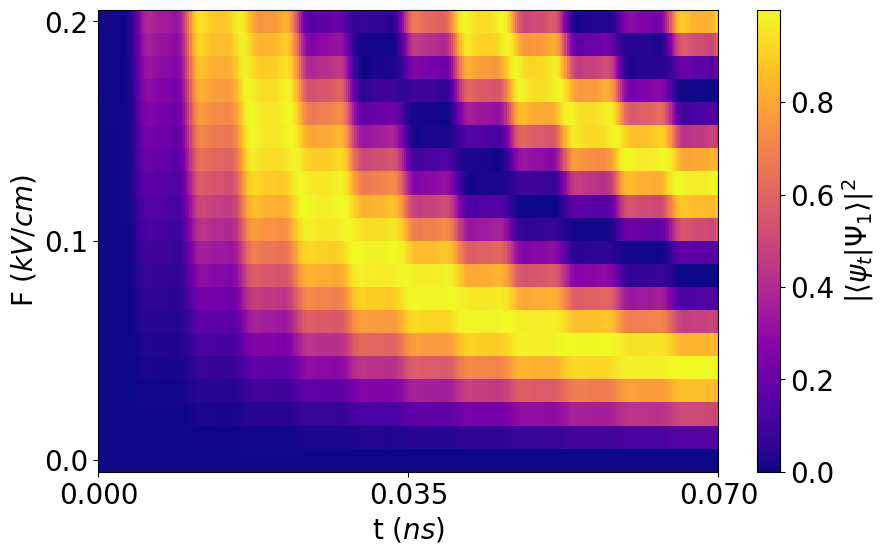

In [85]:
dane4 = np.loadtxt('z4.dat')
linsp_t = 10000*au2ns(np.arange(0, dane4.shape[1]))
linsp_F = np.linspace(0.0, 0.2, dane4.shape[0])

plt.figure(figsize=(10, 6))
plt.pcolormesh(linsp_t, linsp_F, dane4, shading='auto', cmap = 'plasma')
plt.ylabel("F ($kV/cm$)", fontsize=20)
plt.xlim((0.0, 0.07))
plt.xticks([0, 0.035 ,0.07])
plt.yticks([0.0, 0.1, 0.2])
plt.xlabel("t ($ns$)", fontsize=20)
cbar = plt.colorbar() #label=r"$|\langle\psi_t|\Psi_1\rangle|^2$")
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r"$|\langle\psi_t|\Psi_1\rangle|^2$", fontsize=20)
plt.show()